# BioServices – An Overview

**BioServices** is a Python package providing programmatic access to major
Bioinformatics Web Services (e.g., UniProt, KEGG, Ensembl, ChEMBL, BioModels).
It supports both REST and SOAP protocols.

This notebook gives a quick tour of several services.  
Each service has its own dedicated notebook with deeper examples.


In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from bioservices import UniProt, Ensembl, WikiPathways, ChEMBL, KEGG


## UniProt

[UniProt](https://www.uniprot.org/) is the central hub for protein sequence
and functional information.  BioServices wraps its REST API so you can search,
retrieve sequences and map identifiers without leaving Python.


In [2]:
u = UniProt(verbose=False)


In [3]:
# Retrieve the FASTA sequence for ZAP-70 (human tyrosine-protein kinase)
fasta = u.get_fasta("P43403")
print(fasta[:200], "...")


>sp|P43403|ZAP70_HUMAN Tyrosine-protein kinase ZAP-70 OS=Homo sapiens OX=9606 GN=ZAP70 PE=1 SV=1
MPDPAAHLPFFYGSISRAEAEEHLKLAGMADGLFLLRQCLRSLGGYVLSLVHDVRFHHFP
IERQLNGTYAIAGGKAHCGPAELCEFYSRDPDGLPCNLRKPC ...


In [4]:
# Search for ZAP70 in human (NCBI taxonomy 9606), return 3 results
res = u.search("ZAP70+AND+taxonomy_id:9606", limit=3, frmt="tsv",
               columns="accession,id,gene_names,length")
print(res)


Entry	Entry Name	Gene Names	Length
P43403	ZAP70_HUMAN	ZAP70 SRK	619
P22681	CBL_HUMAN	CBL CBL2 RNF55	906
P20963	CD3Z_HUMAN	CD247 CD3Z T3Z TCRZ	164


In [5]:
# Load information for a set of proteins into a DataFrame
df = u.get_df(["ZAP70_HUMAN", "EGFR_HUMAN", "TP53_HUMAN", "BRCA1_HUMAN",
               "MYC_HUMAN", "AKT1_HUMAN", "PTEN_HUMAN", "KRAS_HUMAN"])
df[["Entry", "Entry Name", "Gene Names", "Length"]]


,Entry,Entry Name,Gene Names,Length
0,P43403,ZAP70_HUMAN,ZAP70 SRK,619
1,P60484,PTEN_HUMAN,PTEN MMAC1 TEP1,403
2,P00533,EGFR_HUMAN,EGFR ERBB ERBB1 HER1,1210
3,P31749,AKT1_HUMAN,AKT1 PKB RAC,480
4,Q12888,TP53B_HUMAN,TP53BP1,1972
5,P38398,BRCA1_HUMAN,BRCA1 RNF53,1863
6,P01106,MYC_HUMAN,MYC BHLHE39,454
7,Q3UHF7,ZEP2_MOUSE,Hivep2 Mibp1,2430
8,Q9Y5J5,PHLA3_HUMAN,PHLDA3 TIH1,127
9,Q00900,ZEP2_RAT,Hivep2 Agie-bp1 Mibp1,2437


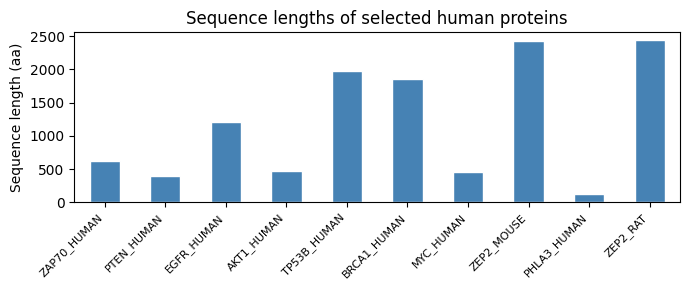

In [6]:
# Visualise the sequence-length distribution
fig, ax = plt.subplots(figsize=(7, 3))
df["Length"].plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
ax.set_xticklabels(df["Entry Name"], rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Sequence length (aa)")
ax.set_title("Sequence lengths of selected human proteins")
plt.tight_layout()
plt.show()


## Ensembl

[Ensembl](https://www.ensembl.org/) provides genome annotation and
comparative genomics data.  Here we look up metadata for the *BRAF* gene.


In [7]:
e = Ensembl()
# BRAF gene (ENSG00000157764)
res = e.get_lookup_by_id("ENSG00000157764", expand=True)
print("Gene name :", res.get("display_name"))
print("Species   :", res.get("species"))
print("Location  : chr", res.get("seq_region_name"), ":",
      res.get("start"), "-", res.get("end"))
print("Biotype   :", res.get("biotype"))
print("#Transcripts:", len(res.get("Transcript", [])))


Gene name : BRAF
Species   : homo_sapiens
Location  : chr 7 : 140719327 - 140924976
Biotype   : protein_coding
#Transcripts: 27


## KEGG

[KEGG](https://www.kegg.jp/) is a comprehensive resource for biological pathways,
genomes and chemical compounds.  Here we search for B-cell related pathways in human.


In [8]:
k = KEGG(verbose=False)
k.organism = "hsa"
results = k.lookfor_pathway("B cell")
print("Pathways matching 'B cell':")
for r in results:
    print(' ', r)


Pathways matching 'B cell':
  map04662 B cell receptor signaling pathway


## ChEMBL

[ChEMBL](https://www.ebi.ac.uk/chembl/) is a large-scale bioactivity database
with data on drug-like molecules and their biological targets.


In [9]:
c = ChEMBL()


In [10]:
# Retrieve information about Aspirin (CHEMBL25)
mol = c.get_molecule("CHEMBL25")
props = mol.get("molecule_properties", {})
print("Preferred name :", mol.get("pref_name"))
print("CHEMBL ID      :", mol.get("molecule_chembl_id"))
print("Mol. weight    :", props.get("mw_freebase"))
print("AlogP          :", props.get("alogp"))
print("Max phase      :", mol.get("max_phase"))


Preferred name : ASPIRIN
CHEMBL ID      : CHEMBL25
Mol. weight    : 180.16
AlogP          : 1.31
Max phase      : 4.0


TEST:   0%|                                                                                             | 0/200 [00:00<?, ?it/s]
WARNING [bioservices.ChEMBL:418]:  More data available (15093). rerun with higherlimit and/or offset 0. Check content of page_meta attribute


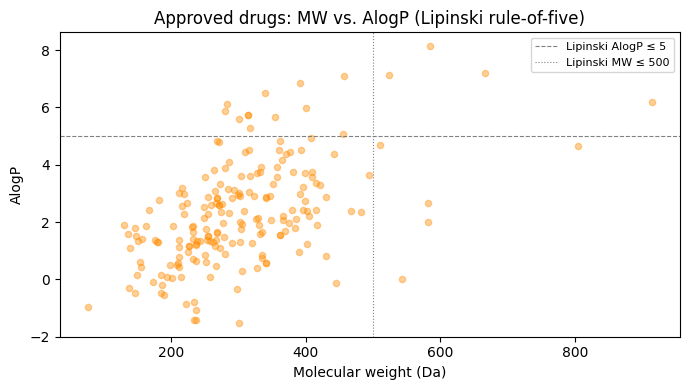

In [12]:
# Retrieve 200 approved drugs and scatter-plot MW vs AlogP (Lipinski rule-of-five)
drugs = c.get_approved_drugs(maxdrugs=200)
df_drugs = pd.DataFrame([
    {
        "name": d.get("pref_name", ""),
        "mw": (d.get("molecule_properties") or {}).get("mw_freebase"),
        "alogp": (d.get("molecule_properties") or {}).get("alogp"),
    }
    for d in drugs if d
])
df_plot = df_drugs.dropna(subset=["mw", "alogp"]).astype({"mw": float, "alogp": float})

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(df_plot["mw"], df_plot["alogp"], alpha=0.4, s=20, color="darkorange")
ax.axhline(5, color="grey", linestyle="--", linewidth=0.8, label="Lipinski AlogP ≤ 5")
ax.axvline(500, color="grey", linestyle=":", linewidth=0.8, label="Lipinski MW ≤ 500")
ax.set_xlabel("Molecular weight (Da)")
ax.set_ylabel("AlogP")
ax.set_title("Approved drugs: MW vs. AlogP (Lipinski rule-of-five)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## Next Steps

This was a brief overview.  Each service has its own dedicated notebook:

- **[UniProt.ipynb](UniProt.ipynb)** – search, retrieve, map identifiers, UniRef
- **[KEGG.ipynb](KEGG.ipynb)** – pathways, compounds, genes
- **[ChEMBL.ipynb](ChEMBL.ipynb)** – molecules, targets, activities
- **[Ensembl.ipynb](Ensembl.ipynb)** – genomic features, variation, comparative genomics
- **[BioModels.ipynb](BioModels.ipynb)** – systems-biology models
- **[InterPro.ipynb](InterPro.ipynb)** – protein domains and families

For the full API reference see the
[BioServices documentation](https://bioservices.readthedocs.io/).
